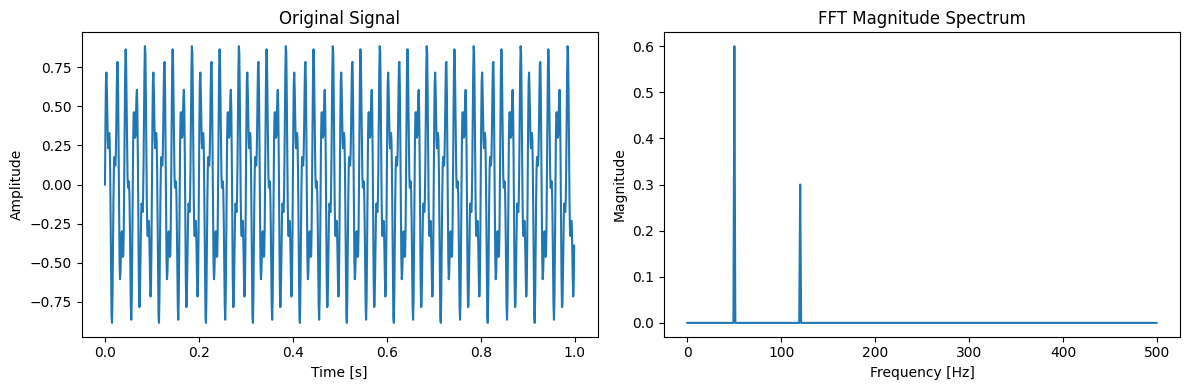

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Generate a signal: combination of 2 sine waves
Fs = 1000  # Sampling frequency (Hz)
T = 1.0 / Fs  # Sampling interval
L = 1000  # Number of samples
t = np.linspace(0.0, L*T, L, endpoint=False)

# Create signal: 50Hz + 120Hz
signal = 0.6 * np.sin(2.0*np.pi*50.0*t) + 0.3 * np.sin(2.0*np.pi*120.0*t)

# Compute FFT
yf = fft(signal)
xf = fftfreq(L, T)[:L//2]  # Positive frequencies only

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, signal)
plt.title('Original Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.plot(xf, 2.0/L * np.abs(yf[0:L//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()


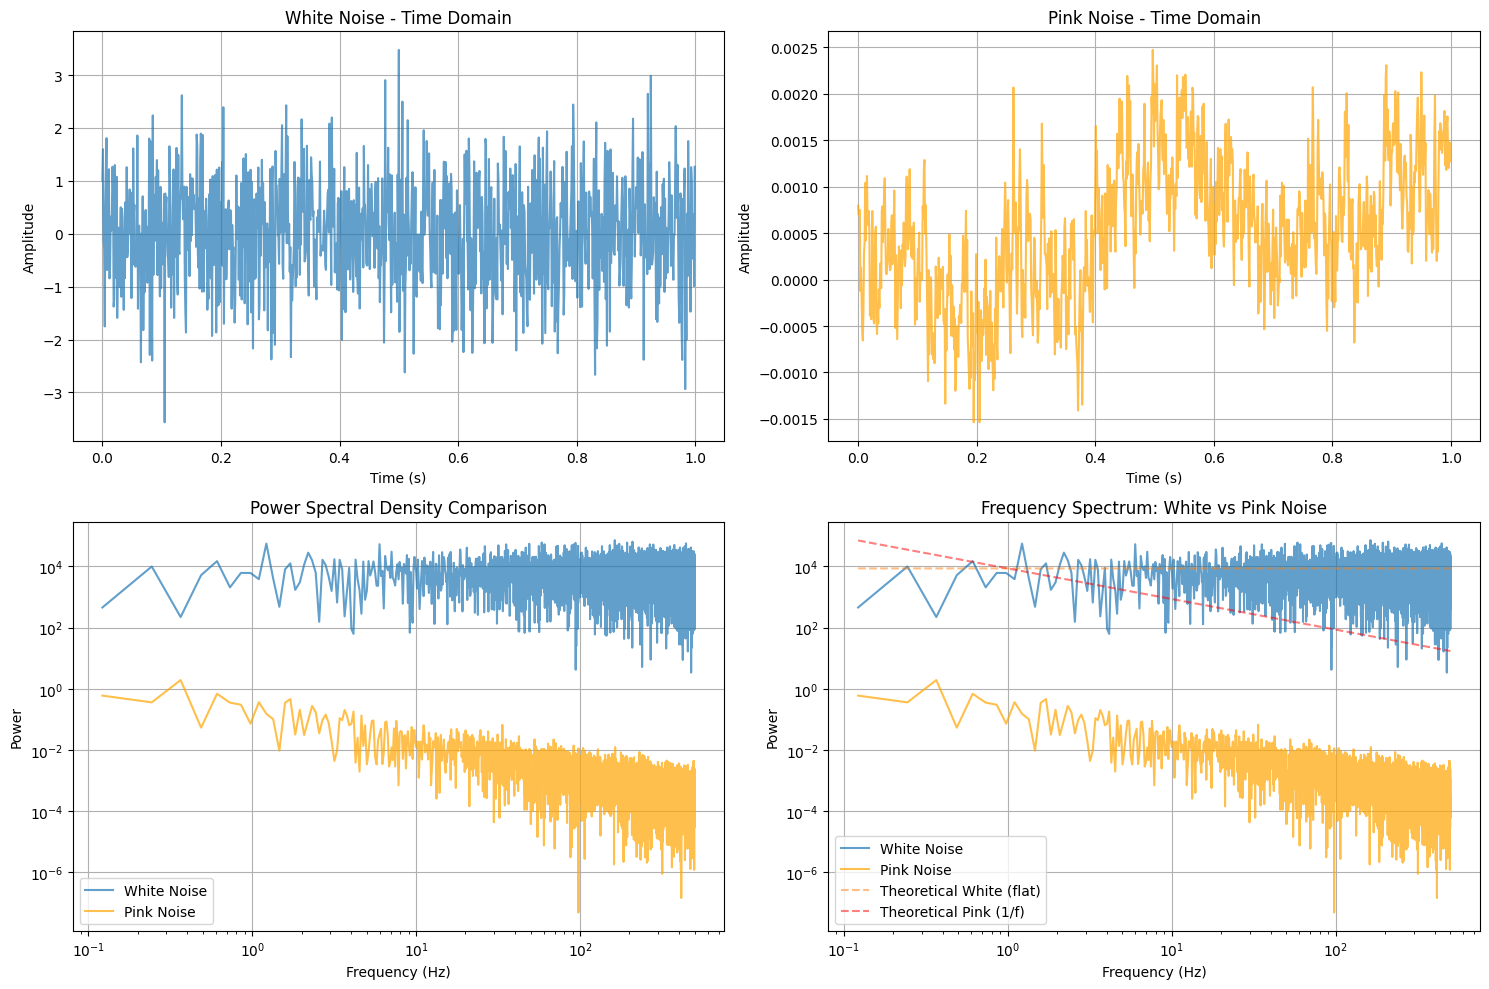

White Noise Statistics:
Mean: -0.0099
Std: 1.0110
Power slope (log-log): -0.04

Pink Noise Statistics:
Mean: 0.0001
Std: 0.0007
Power slope (log-log): -1.11

Expected:
White noise slope ≈ 0
Pink noise slope ≈ -1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

# Parameters
N = 8192              # Number of samples
fs = 1000             # Sampling frequency (Hz)
alpha = 1             # 1/f exponent

# Frequency array
freq = np.fft.fftfreq(N, 1/fs)
freq_pos = freq[:N//2]

# Generate white noise (time and frequency)
white = np.random.normal(0, 1, N)
white_fft = fft(white)

# Generate complex white noise in frequency domain
white_freq = np.random.normal(0, 1, N//2) + 1j * np.random.normal(0, 1, N//2)

# 1/f scaling (avoid division by 0 at freq=0)
scaling = np.ones(N//2)
scaling[1:] = 1 / (np.arange(1, N//2)**(alpha/2))

# Apply scaling to generate pink noise
pink_freq = white_freq * scaling

# Mirror spectrum for IFFT (ensure Hermitian symmetry)
pink_fft_full = np.zeros(N, dtype=complex)
pink_fft_full[:N//2] = pink_freq
pink_fft_full[N//2+1:] = np.conj(pink_freq[1:][::-1])

# Convert back to time domain
pink = np.real(ifft(pink_fft_full))

# PSD (Power Spectral Density)
white_psd = np.abs(white_fft[:N//2])**2
pink_psd = np.abs(pink_fft_full[:N//2])**2

# Time array
t = np.arange(N) / fs

# ---------- Plotting ----------
plt.figure(figsize=(15, 10))

# Time-domain plots
plt.subplot(2, 2, 1)
plt.plot(t[:1000], white[:1000], alpha=0.7)
plt.title('White Noise - Time Domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t[:1000], pink[:1000], color='orange', alpha=0.7)
plt.title('Pink Noise - Time Domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Frequency-domain comparison
plt.subplot(2, 2, 3)
plt.loglog(freq_pos[1:], white_psd[1:], label='White Noise', alpha=0.7)
plt.loglog(freq_pos[1:], pink_psd[1:], label='Pink Noise', alpha=0.7, color='orange')
plt.title('Power Spectral Density Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.legend()
plt.grid(True)

# Overlay with theoretical slopes
plt.subplot(2, 2, 4)
plt.loglog(freq_pos[1:], white_psd[1:], label='White Noise', alpha=0.7)
plt.loglog(freq_pos[1:], pink_psd[1:], label='Pink Noise', alpha=0.7, color='orange')

# Add theoretical reference lines
mean_power = np.mean(white_psd[10:100])
theoretical_white = np.ones_like(freq_pos[1:]) * mean_power
theoretical_pink = mean_power / freq_pos[1:]

plt.loglog(freq_pos[1:], theoretical_white, '--', label='Theoretical White (flat)', alpha=0.5)
plt.loglog(freq_pos[1:], theoretical_pink, '--', label='Theoretical Pink (1/f)', alpha=0.5, color='red')

plt.title('Frequency Spectrum: White vs Pink Noise')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------- Print Statistics ----------
print("White Noise Statistics:")
print(f"Mean: {np.mean(white):.4f}")
print(f"Std: {np.std(white):.4f}")
slope_white = np.polyfit(np.log10(freq_pos[10:100]), np.log10(white_psd[10:100]), 1)[0]
print(f"Power slope (log-log): {slope_white:.2f}")

print("\nPink Noise Statistics:")
print(f"Mean: {np.mean(pink):.4f}")
print(f"Std: {np.std(pink):.4f}")
slope_pink = np.polyfit(np.log10(freq_pos[10:100]), np.log10(pink_psd[10:100]), 1)[0]
print(f"Power slope (log-log): {slope_pink:.2f}")

print("\nExpected:")
print("White noise slope ≈ 0")
print("Pink noise slope ≈ -1")
